## Классические алгоритмы без ансамблирования
В этом ноутбуке вам нужно обучить модели на датасете классификации из предыдущего ноутбука и сравнить результаты. Вам будет предоставлен baseline, на основе которого вы будете доделывать предсказывающие модели. Оценка лабы будет зависеть от ROC-AUC на тестовых данных по следующим критериям:
\
AUC - на тестовых данных
- $AUC \leq 0.75$ - 0 баллов
- $0.75 < AUC \leq 0.76$ - 2 балла
- $0.76 < AUC \leq 0.77$ - 4 балла
- $0.77 < AUC \leq 0.78$ - 6 баллов
- $0.78 < AUC \leq 0.79$ - 8 баллов
- $AUC > 0.79$ - 10 баллов

\
В этой работе запрещено использовать ансамбли моделей (лес, бустинги и т.д.)!

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, accuracy_score

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [5]:
data = pd.read_csv('german.csv', sep=';')
print(data.head())

X = data.iloc[:, 1:].to_numpy()
y = data.iloc[:, 0].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

   Creditability  Account_Balance  Duration_of_Credit_monthly  \
0              1                1                          18   
1              1                1                           9   
2              1                2                          12   
3              1                1                          12   
4              1                1                          12   

   Payment_Status_of_Previous_Credit  Purpose  Credit_Amount  \
0                                  4        2           1049   
1                                  4        0           2799   
2                                  2        9            841   
3                                  4        0           2122   
4                                  4        0           2171   

   Value_Savings_Stocks  Length_of_current_employment  Instalment_per_cent  \
0                     1                             2                    4   
1                     1                             3               

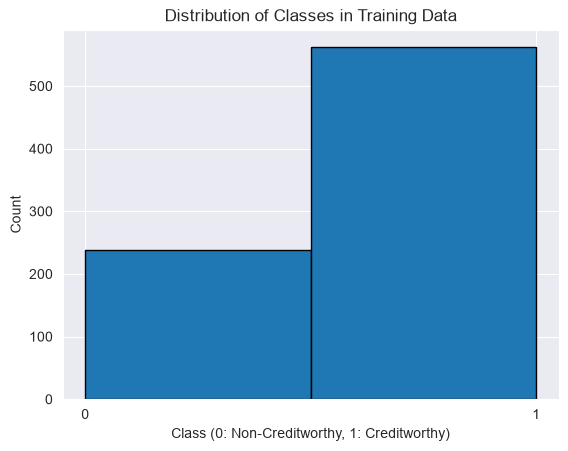

In [40]:
plt.hist(y_train, bins=2, edgecolor='k')
plt.xticks([0, 1])
plt.xlabel('Class (0: Non-Creditworthy, 1: Creditworthy)')
plt.ylabel('Count')
plt.title('Distribution of Classes in Training Data')
plt.show()

In [44]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_regression_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=0.1,
    solver='liblinear'
)
logistic_regression_model.fit(X_train_scaled, y_train)

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=4,
    class_weight='balanced'
)
decision_tree_model.fit(X_train, y_train)

knn_model = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='euclidean'
)
knn_model.fit(X_train_scaled, y_train)

y_prob_logistic = logistic_regression_model.predict_proba(X_test_scaled)[:, 1]
y_prob_decision_tree = decision_tree_model.predict_proba(X_test)[:, 1]
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

y_pred_logistic = logistic_regression_model.predict(X_test_scaled)
y_pred_decision_tree = decision_tree_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test_scaled)


accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
accuracy_decision_tree = accuracy_score(y_test, y_pred_decision_tree)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)
roc_auc_decision_tree = roc_auc_score(y_test, y_prob_decision_tree)
roc_auc_knn = roc_auc_score(y_test, y_prob_knn)

precision_logistic = precision_score(y_test, y_pred_logistic, zero_division=0)
precision_decision_tree = precision_score(y_test, y_pred_decision_tree, zero_division=0)
precision_knn = precision_score(y_test, y_pred_knn, zero_division=0)

recall_logistic = recall_score(y_test, y_pred_logistic, zero_division=0)
recall_decision_tree = recall_score(y_test, y_pred_decision_tree, zero_division=0)
recall_knn = recall_score(y_test, y_pred_knn, zero_division=0)

print(f'Accuracy of Logistic Regression: {accuracy_logistic:.4f}')
print(f'Accuracy of Decision Tree: {accuracy_decision_tree:.4f}')
print(f'Accuracy of K-Nearest Neighbors: {accuracy_knn:.4f}')

print(f'ROC AUC of Logistic Regression: {roc_auc_logistic:.4f}')
print(f'ROC AUC of Decision Tree: {roc_auc_decision_tree:.4f}')
print(f'ROC AUC of K-Nearest Neighbors: {roc_auc_knn:.4f}')

print(f'Precision of Logistic Regression: {precision_logistic:.4f}')
print(f'Precision of Decision Tree: {precision_decision_tree:.4f}')
print(f'Precision of K-Nearest Neighbors: {precision_knn:.4f}')

print(f'Recall of Logistic Regression: {recall_logistic:.4f}')
print(f'Recall of Decision Tree: {recall_decision_tree:.4f}')
print(f'Recall of K-Nearest Neighbors: {recall_knn:.4f}')

Accuracy of Logistic Regression: 0.7500
Accuracy of Decision Tree: 0.6750
Accuracy of K-Nearest Neighbors: 0.7550
ROC AUC of Logistic Regression: 0.7920
ROC AUC of Decision Tree: 0.6929
ROC AUC of K-Nearest Neighbors: 0.7703
Precision of Logistic Regression: 0.7785
Precision of Decision Tree: 0.8230
Precision of K-Nearest Neighbors: 0.7730
Recall of Logistic Regression: 0.8913
Recall of Decision Tree: 0.6739
Recall of K-Nearest Neighbors: 0.9130


## Экспериментируйте
Для получения лучшего качества придется поэкспериментировать. Подсказка: попробуйте оптимизировать гиперпараметры модели